# 01 — EDA & Calibration

Purpose: mine PaySim / IBM AMLSim for realistic parameter distributions
(amount, timing) to calibrate the BetShield agent simulation.

This notebook becomes the basis for the **Methodology → Data Calibration**
section of the report.

In [10]:
import os
print(os.getcwd())
print(os.listdir('../data/raw'))

c:\Users\UDAY\Downloads\betshield_starter\betshield\notebooks
['.gitkeep', 'PS_20174392719_1491204439457_log.csv']


In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Download PaySim from Kaggle and place it at data/raw/paysim.csv
df = pd.read_csv('../data/raw/PS_20174392719_1491204439457_log.csv')
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


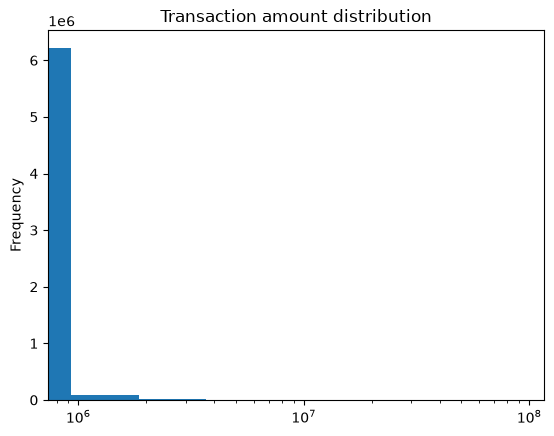

In [7]:
# Q1: amount distribution
df['amount'].plot(kind='hist', bins=100, logx=True, title='Transaction amount distribution')
plt.show()

In [8]:
# Q2: inter-transaction timing per account
# Q3: fraud vs normal ratio
df['isFraud'].value_counts(normalize=True)

isFraud
0    0.998709
1    0.001291
Name: proportion, dtype: float64

In [9]:
df.groupby('type')['isFraud'].agg(['mean', 'sum', 'count'])

,mean,sum,count
type,,,
CASH_IN,0.000000,0,1399284
CASH_OUT,0.001840,4116,2237500
DEBIT,0.000000,0,41432
PAYMENT,0.000000,0,2151495
TRANSFER,0.007688,4097,532909
